# Gradient Boosting

## Definition

Gradient Boosting is an **ensemble technique** based on boosting.

- It combines multiple weak models  
- Models are added sequentially in a stage-wise manner  

## Key Idea

- Start with a simple model  
- Add new models one by one  
- Each new model focuses on correcting the errors of previous models  

## Additive Modeling

This process is known as **additive modeling**:

$$
F(x) = f_0(x) + f_1(x) + f_2(x) + \dots + f_M(x)
$$

- Each $$ f_m(x) $$ is a weak learner  
- The final model is the sum of all learners  

## Learning Process

- At each step:
  - Compute error of current model  
  - Train a new model on that error  
  - Add it to the existing model  

## Bias-Variance Perspective

- Goal: achieve **low bias and low variance**  
- Bias and variance are generally inversely related  

### Strategy

- Use **weak learners (high bias models)**  
- Combine them using additive modeling  
- Reduce bias while controlling variance  

## 

- Sequential learning  
- Error correction at each step  
- Final model is a sum of weak learners  

----
----

## Classification vs Regression in Gradient Boosting

The overall algorithm remains the same for both regression and classification.

- Stage-wise additive modeling  
- Sequential learning  
- Each model corrects the errors of previous models  

## Key Difference

The main difference lies in the **loss function used**.

### Regression

- Uses **least squares loss**:
  
$$
L(y, \hat{y}) = \frac{1}{2}(y - \hat{y})^2
$$

- Predicts continuous values  

### Classification

- Uses **log loss (binary cross-entropy)**:

$$
L(y, F(x)) = \log(1 + e^{-yF(x)})
$$

- Predicts probabilities (via log-odds)

## Important Note

- The **structure of the algorithm does not change**  
- Only the **loss function and residual computation change**  


----
----

# Example

| cgpa | iq  | is_placed |
|------|-----|-----------|
| 6.82 | 118 | 0         |
| 6.36 | 125 | 1         |
| 5.39 | 99  | 1         |
| 5.50 | 106 | 1         |
| 6.39 | 148 | 0         |
| 9.13 | 148 | 1         |
| 7.17 | 147 | 1         |
| 7.72 | 72  | 0         |

In [38]:
import pandas as pd
import numpy as np
import random

df = pd.DataFrame(
    [
        [6.82, 118, 0],
        [6.36, 125, 1],
        [5.39, 99, 1],
        [5.50, 106, 1],
        [6.39, 148, 0],
        [9.13, 148, 1],
        [7.17, 147, 1],
        [7.72, 72, 0]
    ],
    columns=['cgpa', 'iq', 'is_placed']
)

df

,cgpa,iq,is_placed
0,6.82,118,0
1,6.36,125,1
2,5.39,99,1
3,5.50,106,1
4,6.39,148,0
5,9.13,148,1
6,7.17,147,1
7,7.72,72,0


## Model Building in Stages

We construct the model using three stages:

$$
F(x) = f_0(x) + f_1(x) + f_2(x)
$$

## Initial Model

$$
f_0(x)
$$

- A simple model  
- Initialized using the **mean of the output column** (for regression)  
- Acts as the starting point  

## Stage-wise Learning

### Stage 1

$$
F_1(x) = f_0(x) + f_1(x)
$$

- Fit the first weak learner  
- It learns to correct the error of $$ f_0(x) $$  

### Stage 2

$$
F_2(x) = f_0(x) + f_1(x) + f_2(x)
$$

- Add second model  
- It corrects the errors of $$ F_1(x) $$  

### Stage 3

$$
F_3(x) = f_0(x) + f_1(x) + f_2(x)
$$

- Final model after three stages  
- Combines all previous corrections  

## 

- Models are added sequentially  
- Each stage improves the previous one  
- Final model is the sum of all stages

---
---

## Stage 1: Initial Model (Log-Odds and Probability)

In classification, we do not initialize using the mean of the target.

Instead, we use **log-odds** of the target variable.

## Log-Odds

$$
F_0 = \log \left( \frac{\text{number of 1s}}{\text{number of 0s}} \right)
$$

- Log base $$ e $$ is used  
- Not log base 10  

### For our dataset:

- Number of 1s = 5  
- Number of 0s = 3  

$$
F_0 = \log\left(\frac{5}{3}\right) \approx 0.51
$$

This value is assigned to all data points:

$$
\text{pre1 (log-odds)} = 0.51
$$

## Converting Log-Odds to Probability

We convert log-odds into probability using the sigmoid function:

$$
p = \frac{1}{1 + e^{-F_0}}
$$

## Interpretation

- $$ F_0 $$ represents log-odds  
- $$ p $$ represents probability of class 1 (is_placed = 1)  
- This probability will be used to compute residuals  

## Important Note

- Residuals will be calculated using:
  - Actual values: `is_placed`  
  - Predicted probabilities: $$ p $$  

## Summary

- Initialize with log-odds  
- Convert log-odds to probability  
- Use probability to compute residuals in next step  

In [39]:
df['pre1(log-odds)'] = np.log(5/3)

df

,cgpa,iq,is_placed,pre1(log-odds)
0,6.82,118,0,0.510826
1,6.36,125,1,0.510826
2,5.39,99,1,0.510826
3,5.50,106,1,0.510826
4,6.39,148,0,0.510826
5,9.13,148,1,0.510826
6,7.17,147,1,0.510826
7,7.72,72,0,0.510826


In [40]:
df['pre1(prob)'] = 1 / (1 + np.exp(-df['pre1(log-odds)']))

df

,cgpa,iq,is_placed,pre1(log-odds),pre1(prob)
0,6.82,118,0,0.510826,0.625
1,6.36,125,1,0.510826,0.625
2,5.39,99,1,0.510826,0.625
3,5.50,106,1,0.510826,0.625
4,6.39,148,0,0.510826,0.625
5,9.13,148,1,0.510826,0.625
6,7.17,147,1,0.510826,0.625
7,7.72,72,0,0.510826,0.625


## Interpretation of Initial Probabilities

The probability obtained from log-odds reflects a behavior similar to the mean-based initialization in regression.

- All data points receive the same initial probability  
- This is because the initial model is a constant (log-odds)  

## Observation

- The computed probability is greater than 0.5  
- Therefore, all predictions are classified as:

$$
\hat{y} = 1 \quad (\text{placed})
$$

## Implication

- The initial model predicts that **all students are placed**  
- This is a naive baseline model  

-----
----

In [41]:
# calculating residuals for stage 1

df['res1'] = df['is_placed'] - df['pre1(prob)']

df

,cgpa,iq,is_placed,pre1(log-odds),pre1(prob),res1
0,6.82,118,0,0.510826,0.625,-0.625
1,6.36,125,1,0.510826,0.625,0.375
2,5.39,99,1,0.510826,0.625,0.375
3,5.50,106,1,0.510826,0.625,0.375
4,6.39,148,0,0.510826,0.625,-0.625
5,9.13,148,1,0.510826,0.625,0.375
6,7.17,147,1,0.510826,0.625,0.375
7,7.72,72,0,0.510826,0.625,-0.625


## Training First Weak Learner on Residuals

Now we train a new model that learns from the mistakes of the previous model.

### Input and Output

- **Input features** remain the same:
  - cgpa  
  - iq  

- **Target variable** is updated:
  - $$ \text{res1} = y - p $$  

### Important Note

- We use a **Decision Tree Regressor**, not a classifier  
- Reason:
  - Residuals are continuous values  
  - The model needs to predict numerical corrections  

### Objective

- Learn the error made by the initial model  
- Predict how much correction is needed for each data point  

## 

- Same input features  
- New target = residuals  
- Model learns errors, not labels
---
---

In [42]:
from sklearn.tree import DecisionTreeRegressor

# features and target
X = df[['cgpa', 'iq']]
y = df['res1']

In [43]:
# train first weak learner
dt1 = DecisionTreeRegressor(max_leaf_nodes=3)
dt1.fit(X, y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

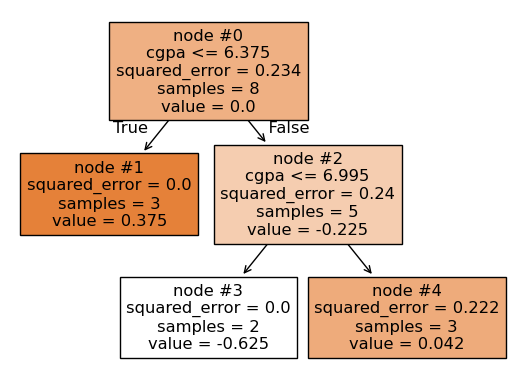

In [44]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plot_tree(dt1, feature_names=['cgpa', 'iq'], filled=True , node_ids=True)
plt.show()

In [45]:
# predictions (corrections)
df['dt1_pred'] = dt1.predict(X)

df

,cgpa,iq,is_placed,pre1(log-odds),pre1(prob),res1,dt1_pred
0,6.82,118,0,0.510826,0.625,-0.625,-0.625000
1,6.36,125,1,0.510826,0.625,0.375,0.375000
2,5.39,99,1,0.510826,0.625,0.375,0.375000
3,5.50,106,1,0.510826,0.625,0.375,0.375000
4,6.39,148,0,0.510826,0.625,-0.625,-0.625000
5,9.13,148,1,0.510826,0.625,0.375,0.041667
6,7.17,147,1,0.510826,0.625,0.375,0.041667
7,7.72,72,0,0.510826,0.625,-0.625,0.041667


## Updating Model in Classification (Leaf Values)

In regression:
- The output of each leaf is directly added to the model  

In classification:
- Residuals are based on probabilities  
- We cannot directly add probabilities to log-odds  
- Therefore, we must convert updates into **log-odds space**

## Leaf-wise Update

For each leaf (region), we compute:

$$
\gamma = \frac{\sum (\text{residual})}{\sum \left(p \cdot (1 - p)\right)}
$$

Where:
- residual = $$ y - p $$  
- $$ p $$ = predicted probability from previous model  

This converts the update into a value compatible with log-odds.

## Key Idea

- Each leaf contains a subset of data points  
- We compute a separate $$ \gamma $$ for each leaf  
- This value represents the correction in log-odds space  

## Identifying Leaf Membership

To determine which data point belongs to which leaf, we use:

```python
df['leaf_entry1'] = dt1.apply(X)

In [46]:
df['leaf_entry1'] = dt1.apply(df[['cgpa', 'iq']])
df

,cgpa,iq,is_placed,pre1(log-odds),pre1(prob),res1,dt1_pred,leaf_entry1
0,6.82,118,0,0.510826,0.625,-0.625,-0.625000,3
1,6.36,125,1,0.510826,0.625,0.375,0.375000,1
2,5.39,99,1,0.510826,0.625,0.375,0.375000,1
3,5.50,106,1,0.510826,0.625,0.375,0.375000,1
4,6.39,148,0,0.510826,0.625,-0.625,-0.625000,3
5,9.13,148,1,0.510826,0.625,0.375,0.041667,4
6,7.17,147,1,0.510826,0.625,0.375,0.041667,4
7,7.72,72,0,0.510826,0.625,-0.625,0.041667,4


## Calculating γ for One Leaf (Example)

We compute the update value $$ \gamma $$ for a specific leaf to understand the formula.

### Step 1: Choose a Leaf

From `leaf_entry1`, consider:

$$
\text{leaf } = 1
$$

Rows in this leaf:
- Index 1, 2, 3  

---

### Step 2: Extract Values

For these rows:

- $$ \text{res1} = [0.375, 0.375, 0.375] $$
- $$ p = 0.625 $$ (same for all rows)

---

### Step 3: Apply Formula

$$
\gamma = \frac{\sum (\text{residual})}{\sum \left(p(1 - p)\right)}
$$

#### Numerator

$$
0.375 + 0.375 + 0.375 = 1.125
$$

#### Denominator

$$
p(1 - p) = 0.625 \times 0.375 = 0.234375
$$

$$
\sum = 0.234375 + 0.234375 + 0.234375 = 0.703125
$$

---

### Step 4: Final Value

$$
\gamma = \frac{1.125}{0.703125} \approx 1.60
$$

---

## Interpretation

- This value is the **log-odds correction** for this leaf  
- It will be added to the previous model for all points in this leaf  

## 

- Compute γ per leaf  
- Use only data points inside that leaf  
- This value updates the model in the next step  

In [48]:
# function to compute gamma (log-odds update) for each leaf

def return_logs(leaf):
    temp_df = df[df['leaf_entry1'] == leaf]
    
    num = temp_df['res1'].sum()
    den = (temp_df['pre1(prob)'] * (1 - temp_df['pre1(prob)'])).sum()
    
    return round(num / den, 2)

In [49]:
# compute gamma (log-odds update) for each leaf and map back to rows

# get unique leaf ids
leaves = df['leaf_entry1'].unique()

# compute gamma for each leaf
gamma_map = {leaf: return_logs(leaf) for leaf in leaves}

# create new column with gamma values
df['gamma1'] = df['leaf_entry1'].map(gamma_map)

df

,cgpa,iq,is_placed,pre1(log-odds),pre1(prob),res1,dt1_pred,leaf_entry1,gamma1
0,6.82,118,0,0.510826,0.625,-0.625,-0.625000,3,-2.67
1,6.36,125,1,0.510826,0.625,0.375,0.375000,1,1.60
2,5.39,99,1,0.510826,0.625,0.375,0.375000,1,1.60
3,5.50,106,1,0.510826,0.625,0.375,0.375000,1,1.60
4,6.39,148,0,0.510826,0.625,-0.625,-0.625000,3,-2.67
5,9.13,148,1,0.510826,0.625,0.375,0.041667,4,0.18
6,7.17,147,1,0.510826,0.625,0.375,0.041667,4,0.18
7,7.72,72,0,0.510826,0.625,-0.625,0.041667,4,0.18


In [50]:
# update log-odds
df['pre2(log-odds)'] = df['pre1(log-odds)'] + df['gamma1']

In [51]:
# convert to probability
df['pre2(prob)'] = 1 / (1 + np.exp(-df['pre2(log-odds)']))

# compute new residuals
df['res2'] = df['is_placed'] - df['pre2(prob)']

df

,cgpa,iq,is_placed,pre1(log-odds),pre1(prob),res1,dt1_pred,leaf_entry1,gamma1,pre2(log-odds),pre2(prob),res2
0,6.82,118,0,0.510826,0.625,-0.625,-0.625000,3,-2.67,-2.159174,0.103477,-0.103477
1,6.36,125,1,0.510826,0.625,0.375,0.375000,1,1.60,2.110826,0.891951,0.108049
2,5.39,99,1,0.510826,0.625,0.375,0.375000,1,1.60,2.110826,0.891951,0.108049
3,5.50,106,1,0.510826,0.625,0.375,0.375000,1,1.60,2.110826,0.891951,0.108049
4,6.39,148,0,0.510826,0.625,-0.625,-0.625000,3,-2.67,-2.159174,0.103477,-0.103477
5,9.13,148,1,0.510826,0.625,0.375,0.041667,4,0.18,0.690826,0.666151,0.333849
6,7.17,147,1,0.510826,0.625,0.375,0.041667,4,0.18,0.690826,0.666151,0.333849
7,7.72,72,0,0.510826,0.625,-0.625,0.041667,4,0.18,0.690826,0.666151,-0.666151


In [52]:
# Step: Train second decision tree on new residuals

X = df[['cgpa', 'iq']]
y2 = df['res2']

dt2 = DecisionTreeRegressor(max_leaf_nodes=3)
dt2.fit(X, y2)

# predictions (corrections)
df['dt2_pred'] = dt2.predict(X)

df

,cgpa,iq,is_placed,pre1(log-odds),pre1(prob),res1,dt1_pred,leaf_entry1,gamma1,pre2(log-odds),pre2(prob),res2,dt2_pred
0,6.82,118,0,0.510826,0.625,-0.625,-0.625000,3,-2.67,-2.159174,0.103477,-0.103477,0.023439
1,6.36,125,1,0.510826,0.625,0.375,0.375000,1,1.60,2.110826,0.891951,0.108049,0.023439
2,5.39,99,1,0.510826,0.625,0.375,0.375000,1,1.60,2.110826,0.891951,0.108049,0.023439
3,5.50,106,1,0.510826,0.625,0.375,0.375000,1,1.60,2.110826,0.891951,0.108049,0.023439
4,6.39,148,0,0.510826,0.625,-0.625,-0.625000,3,-2.67,-2.159174,0.103477,-0.103477,0.023439
5,9.13,148,1,0.510826,0.625,0.375,0.041667,4,0.18,0.690826,0.666151,0.333849,0.333849
6,7.17,147,1,0.510826,0.625,0.375,0.041667,4,0.18,0.690826,0.666151,0.333849,0.333849
7,7.72,72,0,0.510826,0.625,-0.625,0.041667,4,0.18,0.690826,0.666151,-0.666151,-0.666151


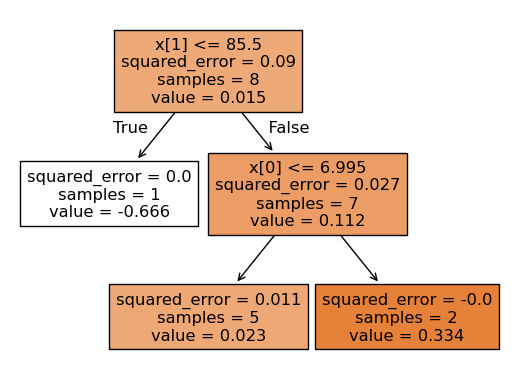

In [54]:
plot_tree(dt2 , filled=True)
plt.show()

In [55]:
# find leaf entries for second tree

df['leaf_entry2'] = dt2.apply(X)

df

,cgpa,iq,is_placed,pre1(log-odds),pre1(prob),res1,dt1_pred,leaf_entry1,gamma1,pre2(log-odds),pre2(prob),res2,dt2_pred,leaf_entry2
0,6.82,118,0,0.510826,0.625,-0.625,-0.625000,3,-2.67,-2.159174,0.103477,-0.103477,0.023439,3
1,6.36,125,1,0.510826,0.625,0.375,0.375000,1,1.60,2.110826,0.891951,0.108049,0.023439,3
2,5.39,99,1,0.510826,0.625,0.375,0.375000,1,1.60,2.110826,0.891951,0.108049,0.023439,3
3,5.50,106,1,0.510826,0.625,0.375,0.375000,1,1.60,2.110826,0.891951,0.108049,0.023439,3
4,6.39,148,0,0.510826,0.625,-0.625,-0.625000,3,-2.67,-2.159174,0.103477,-0.103477,0.023439,3
5,9.13,148,1,0.510826,0.625,0.375,0.041667,4,0.18,0.690826,0.666151,0.333849,0.333849,4
6,7.17,147,1,0.510826,0.625,0.375,0.041667,4,0.18,0.690826,0.666151,0.333849,0.333849,4
7,7.72,72,0,0.510826,0.625,-0.625,0.041667,4,0.18,0.690826,0.666151,-0.666151,-0.666151,1


In [56]:
# function will work same, just change column references if needed

def return_logs2(leaf):
    temp_df = df[df['leaf_entry2'] == leaf]
    
    num = temp_df['res2'].sum()
    den = (temp_df['pre2(prob)'] * (1 - temp_df['pre2(prob)'])).sum()
    
    return round(num / den, 2)

# compute gamma for each leaf
gamma_map2 = {leaf: return_logs2(leaf) for leaf in df['leaf_entry2'].unique()}

df['gamma2'] = df['leaf_entry2'].map(gamma_map2)

df

,cgpa,iq,is_placed,pre1(log-odds),pre1(prob),res1,dt1_pred,leaf_entry1,gamma1,pre2(log-odds),pre2(prob),res2,dt2_pred,leaf_entry2,gamma2
0,6.82,118,0,0.510826,0.625,-0.625,-0.625000,3,-2.67,-2.159174,0.103477,-0.103477,0.023439,3,0.25
1,6.36,125,1,0.510826,0.625,0.375,0.375000,1,1.60,2.110826,0.891951,0.108049,0.023439,3,0.25
2,5.39,99,1,0.510826,0.625,0.375,0.375000,1,1.60,2.110826,0.891951,0.108049,0.023439,3,0.25
3,5.50,106,1,0.510826,0.625,0.375,0.375000,1,1.60,2.110826,0.891951,0.108049,0.023439,3,0.25
4,6.39,148,0,0.510826,0.625,-0.625,-0.625000,3,-2.67,-2.159174,0.103477,-0.103477,0.023439,3,0.25
5,9.13,148,1,0.510826,0.625,0.375,0.041667,4,0.18,0.690826,0.666151,0.333849,0.333849,4,1.50
6,7.17,147,1,0.510826,0.625,0.375,0.041667,4,0.18,0.690826,0.666151,0.333849,0.333849,4,1.50
7,7.72,72,0,0.510826,0.625,-0.625,0.041667,4,0.18,0.690826,0.666151,-0.666151,-0.666151,1,-3.00


In [57]:
# update model again

df['pre3(log-odds)'] = df['pre2(log-odds)'] + df['gamma2']

df['pre3(prob)'] = 1 / (1 + np.exp(-df['pre3(log-odds)']))

df['res3'] = df['is_placed'] - df['pre3(prob)']

df

,cgpa,iq,is_placed,pre1(log-odds),pre1(prob),res1,dt1_pred,leaf_entry1,gamma1,pre2(log-odds),pre2(prob),res2,dt2_pred,leaf_entry2,gamma2,pre3(log-odds),pre3(prob),res3
0,6.82,118,0,0.510826,0.625,-0.625,-0.625000,3,-2.67,-2.159174,0.103477,-0.103477,0.023439,3,0.25,-1.909174,0.129074,-0.129074
1,6.36,125,1,0.510826,0.625,0.375,0.375000,1,1.60,2.110826,0.891951,0.108049,0.023439,3,0.25,2.360826,0.913791,0.086209
2,5.39,99,1,0.510826,0.625,0.375,0.375000,1,1.60,2.110826,0.891951,0.108049,0.023439,3,0.25,2.360826,0.913791,0.086209
3,5.50,106,1,0.510826,0.625,0.375,0.375000,1,1.60,2.110826,0.891951,0.108049,0.023439,3,0.25,2.360826,0.913791,0.086209
4,6.39,148,0,0.510826,0.625,-0.625,-0.625000,3,-2.67,-2.159174,0.103477,-0.103477,0.023439,3,0.25,-1.909174,0.129074,-0.129074
5,9.13,148,1,0.510826,0.625,0.375,0.041667,4,0.18,0.690826,0.666151,0.333849,0.333849,4,1.50,2.190826,0.899423,0.100577
6,7.17,147,1,0.510826,0.625,0.375,0.041667,4,0.18,0.690826,0.666151,0.333849,0.333849,4,1.50,2.190826,0.899423,0.100577
7,7.72,72,0,0.510826,0.625,-0.625,0.041667,4,0.18,0.690826,0.666151,-0.666151,-0.666151,1,-3.00,-2.309174,0.090366,-0.090366


## Evaluating Predictions

After the final iteration, we evaluate the model using predicted probabilities.

## Final Probability

We use the latest probability column:

$$
p(x) = \text{pre3(prob)}
$$

## Convert to Class Labels

Using threshold 0.5:

$$
\hat{y} =
\begin{cases}
1 & \text{if } p(x) > 0.5 \\
0 & \text{otherwise}
\end{cases}
$$

## Code

```python
# final prediction (classification)
df['y_pred'] = (df['pre3(prob)'] > 0.5).astype(int)

df[['is_placed', 'pre3(prob)', 'y_pred']]

In [61]:
# final prediction (classification)
df['y_pred'] = (df['pre3(prob)'] > 0.5).astype(int)

df[['is_placed', 'pre3(prob)', 'y_pred']]

,is_placed,pre3(prob),y_pred
0,0,0.129074,0
1,1,0.913791,1
2,1,0.913791,1
3,1,0.913791,1
4,0,0.129074,0
5,1,0.899423,1
6,1,0.899423,1
7,0,0.090366,0


In [62]:
from sklearn.metrics import accuracy_score

In [63]:
accuracy = (df['is_placed'] == df['y_pred']).mean()
accuracy

np.float64(1.0)

## Final Results

| is_placed | pre3(prob) | y_pred |
|-----------|------------|--------|
| 0         | 0.129074   | 0      |
| 1         | 0.913791   | 1      |
| 1         | 0.913791   | 1      |
| 1         | 0.913791   | 1      |
| 0         | 0.129074   | 0      |
| 1         | 0.899423   | 1      |
| 1         | 0.899423   | 1      |
| 0         | 0.090366   | 0      |

## Accuracy

$$
\text{Accuracy} = 1.0
$$

## Interpretation

- All predictions match the actual values  
- The model correctly classified every data point  
- Probabilities are close to 0 or 1, indicating strong confidence  

## Key Observation

- Gradient Boosting successfully minimized classification error  
- With multiple iterations, the model refined predictions effectively  

## Important Note

- Perfect accuracy on small datasets may indicate overfitting  
- In real-world scenarios, evaluation should be done on unseen data  

## Summary

- Final model achieved perfect classification  
- Predictions are obtained from boosted log-odds model  
- Performance improves with each boosting iteration  

In [66]:
df[['res1','res2','res3']]

,res1,res2,res3
0,-0.625,-0.103477,-0.129074
1,0.375,0.108049,0.086209
2,0.375,0.108049,0.086209
3,0.375,0.108049,0.086209
4,-0.625,-0.103477,-0.129074
5,0.375,0.333849,0.100577
6,0.375,0.333849,0.100577
7,-0.625,-0.666151,-0.090366


## Residual Analysis Across Iterations

| Index | res1     | res2      | res3      |
|-------|----------|-----------|-----------|
| 0     | -0.625   | -0.103477 | -0.129074 |
| 1     | 0.375    | 0.108049  | 0.086209  |
| 2     | 0.375    | 0.108049  | 0.086209  |
| 3     | 0.375    | 0.108049  | 0.086209  |
| 4     | -0.625   | -0.103477 | -0.129074 |
| 5     | 0.375    | 0.333849  | 0.100577  |
| 6     | 0.375    | 0.333849  | 0.100577  |
| 7     | -0.625   | -0.666151 | -0.090366 |

## Key Observations

1. **Residual Magnitude Decreases**
   - Initial residuals (res1) are large  
   - Later residuals (res2, res3) are smaller  
   - Indicates error is being reduced step-by-step  

2. **Convergence Towards Zero**
   - Residuals are moving closer to zero  
   - Model is improving predictions iteratively  

3. **Error Correction Behavior**
   - Each new tree focuses on remaining errors  
   - Misclassified or high-error points get more attention  

4. **Non-Uniform Reduction**
   - Some points improve faster than others  
   - Example:
     - Index 7 shows large correction in res2 → refined in res3  

5. **Sign of Residual**
   - Positive → underestimation (model predicted lower probability)  
   - Negative → overestimation (model predicted higher probability)  

## Insight

> Gradient Boosting works by iteratively reducing residuals until they approach zero.

## Conclusion

- Residuals shrinking → model learning effectively  
- Final stage residuals are small → predictions are accurate  

## Prediction on New Data Using Trained Boosting Model

To make predictions on new data, we follow the same steps used during training.

## Steps

1. Start with initial log-odds $$ F_0 $$  
2. Add updates from each tree (leaf-wise $$ \gamma $$)  
3. Convert final log-odds to probability  
4. Apply threshold to get class  

---

## Code

```python
def predict_boosting(x_input):
    # convert input to DataFrame
    x_df = pd.DataFrame([x_input], columns=['cgpa', 'iq'])
    
    F = np.log(5/3)
    
    leaf1 = dt1.apply(x_df)[0]
    gamma1_val = gamma_map[leaf1]
    F += gamma1_val
    
    leaf2 = dt2.apply(x_df)[0]
    gamma2_val = gamma_map2[leaf2]
    F += gamma2_val
    
    p = 1 / (1 + np.exp(-F))
    y_pred = 1 if p > 0.5 else 0
    
    return p, y_pred

In [83]:
def predict_boosting(x_input):
    # convert input to DataFrame
    x_df = pd.DataFrame([x_input], columns=['cgpa', 'iq'])
    
    F = np.log(5/3)
    
    leaf1 = dt1.apply(x_df)[0]
    gamma1_val = gamma_map[leaf1]
    F += gamma1_val
    
    leaf2 = dt2.apply(x_df)[0]
    gamma2_val = gamma_map2[leaf2]
    F += gamma2_val
    
    p = 1 / (1 + np.exp(-F))
    y_pred = 1 if p > 0.5 else 0
    
    return p, y_pred

In [84]:
# new data point
x_new = [7.5, 120]

prob, pred = predict_boosting(x_new)

print("Probability:", prob)
print("Prediction:", pred)

Probability: 0.8994226182933366
Prediction: 1


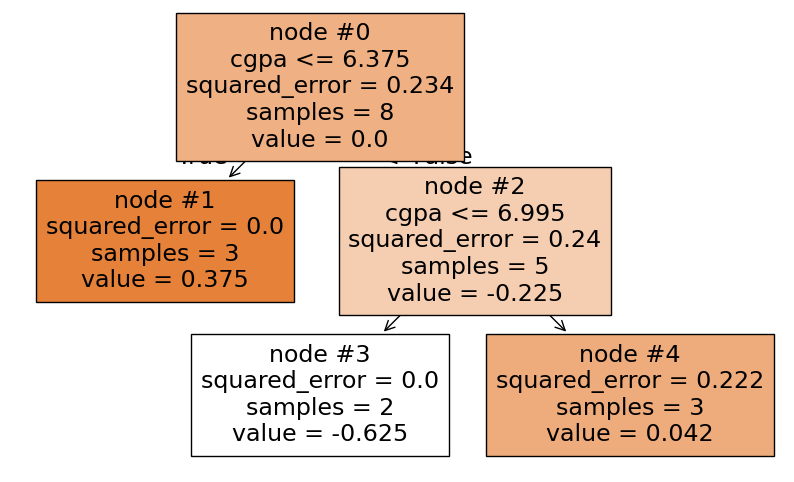

In [77]:
# Model 1: Initial model using log-odds

# Model 2: First decision tree (trained on residuals)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plot_tree(dt1, feature_names=['cgpa', 'iq'], filled=True, node_ids=True)
plt.show()

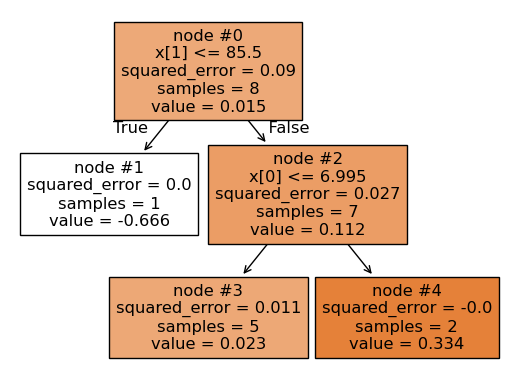

In [78]:
# model 3
plot_tree(dt2, filled=True , node_ids=True)
plt.show()

# Important Formulas: Gradient Boosting for Classification

## 1. Additive Model

$$
F(x) = f_0(x) + \sum_{m=1}^{M} f_m(x)
$$

---

## 2. Log-Odds Representation

$$
F(x) = \log \left( \frac{p(x)}{1 - p(x)} \right)
$$

---

## 3. Initial Model (Log-Odds)

$$
F_0 = \log \left( \frac{\text{number of 1s}}{\text{number of 0s}} \right)
$$

---

## 4. Sigmoid Function (Probability)

$$
p(x) = \frac{1}{1 + e^{-F(x)}}
$$

---

## 5. Loss Function (Log Loss)

$$
L(y, F(x)) = \log(1 + e^{-yF(x)})
$$

---

## 6. Pseudo-Residuals

$$
r_i = y_i - p_i
$$

Where:

$$
p_i = \frac{1}{1 + e^{-F(x_i)}}
$$

---

## 7. Leaf-wise Update (Gamma)

$$
\gamma_{jm} = \frac{\sum_{x_i \in R_{jm}} (y_i - p_i)}{\sum_{x_i \in R_{jm}} p_i(1 - p_i)}
$$

---

## 8. Model Update

$$
F_m(x) = F_{m-1}(x) + \gamma_{jm}
\quad \text{for } x \in R_{jm}
$$

---

## 9. Final Probability

$$
p(x) = \frac{1}{1 + e^{-F_M(x)}}
$$

---

## 10. Final Prediction

$$
\hat{y} =
\begin{cases}
1 & \text{if } p(x) > 0.5 \\
0 & \text{otherwise}
\end{cases}
$$

---

## Summary

- Model learns **log-odds**  
- Converts to probability using **sigmoid**  
- Updates are computed **per leaf**  
- Residuals guide learning at each step  